In [1]:
import os
import json
from datetime import datetime
import numpy as np


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec
import seaborn_image as isns

from scipy.constants import Boltzmann as kb
#from hdr.oop_diffusion import *
#from hdr.utils import *
#from hdr.analytical_solution import *

import warnings

/Users/korsk/Documents/Github/ConfinedDiffusion/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
from scipy.linalg import inv
#matplotlib.use('Qt5Agg')

from scipy.optimize import curve_fit

def savefig(name):
   plt.savefig(os.path.join(OUTDIR, f"{name}.pdf"))
   plt.close()
import os
OUTDIR = "mj_diffusion_mar28_plots"
os.makedirs(OUTDIR, exist_ok=True)

#  --------------------------------------------------------------------------------
# MAIN CLASS
#  --------------------------------------------------------------------------------

import numpy as np
from tqdm import tqdm


class PeriodicCubeRandomWalkGPT:
    """
    Brownian diffusion in a cubic box with periodic boundary conditions.
    """

    def __init__(self, N, dt, steps, D, box_length=1):
        self.N = N
        self.D = D
        self.dt = dt
        self.steps = steps
        self.box_length = box_length

        self.InitializeSimulation()

    # ------------------------------------------------------------------
    # INITIALIZATION
    # ------------------------------------------------------------------
    def InitializeSimulation(self):
        print(f'Starting Position: {self.box_length/2} \n Diffusion: {self.D} \n')
        # Initial wrapped positions
        self.currPos = np.ones(shape=(3, self.N)) * (self.box_length/2) #np.random.uniform(0, self.box_length, size=(3, self.N))

        # Unwrapped positions (REQUIRED for correct MSD)
        self.unwrappedPos = self.currPos.copy()

        # Trajectory storage (wrapped, as before)
        self.TRAJ = [self.currPos.copy()]

    # ------------------------------------------------------------------
    # SINGLE STEP
    # ------------------------------------------------------------------
    def SingleStep(self):
        """
        Perform one diffusion step with periodic boundary conditions.
        """
        sigma = np.sqrt(2 * self.D * self.dt)

        dR = sigma * np.random.randn(3, self.N)

        # Update unwrapped positions (FIX for MSD)
        self.unwrappedPos += dR

        # Wrapped positions for storage / visualization
        self.currPos = self.unwrappedPos #% self.box_length
        #print(self.currPos)
        self.TRAJ.append(self.currPos.copy())

    # ------------------------------------------------------------------
    # RUN SIMULATION
    # ------------------------------------------------------------------
    def runSimulation(self):
        for _ in tqdm(range(self.steps)):
            self.SingleStep()

    # ------------------------------------------------------------------
    # DIRECT MSD (CORRECT, BUT O(T^2))
    # ------------------------------------------------------------------
    def getMeanSquaredDisplacement(self):
        """
        Computes MSD_i(j) = <|r(t+i) - r(t)|^2>_t
        using UNWRAPPED coordinates (correct under PBCs).

        Returns array of shape (T, N)
        """
        traj = self.unwrappedPosHistory()
        T, _, N = traj.shape

        msd = np.zeros((T, N))

        for i in tqdm(range(T)):
            disp = traj[i:] - traj[:T - i]
            msd[i] = np.mean(np.sum(disp**2, axis=1), axis=0)

        self.MSD = msd

    # ------------------------------------------------------------------
    # DIRECT MSD, DECOUPLED
    # ------------------------------------------------------------------
    def getMeanSquaredDisplacementDecoupled(self):
        """
        MSD split into xy and z components (correct under PBCs).
        """
        traj = self.unwrappedPosHistory()
        T, _, N = traj.shape

        msd_xy = np.zeros((T, N))
        msd_z = np.zeros((T, N))

        for i in range(T):
            disp = traj[i:] - traj[:T - i]
            msd_xy[i] = np.mean(disp[:, 0]**2 + disp[:, 1]**2, axis=0)
            msd_z[i] = np.mean(disp[:, 2]**2, axis=0)

        self.MSD_xy = msd_xy
        self.MSD_z = msd_z
        self.MSD = msd_xy + msd_z

    # ------------------------------------------------------------------
    # FFT-BASED MSD (FAST)
    # ------------------------------------------------------------------
    def getMeanSquaredDisplacementFFT(self):
        """
        FFT-based time-averaged MSD.
        Correct under periodic boundary conditions
        using unwrapped trajectories.
        """
        traj = self.unwrappedPosHistory()   # (T, 3, N)
        T, _, N = traj.shape

        msd = np.zeros((T, N))

        for j in range(N):
            r = traj[:, :, j]          # (T, 3)
            r2 = np.sum(r**2, axis=1)  # |r(t)|^2

            # ---- autocorrelation <r(t) · r(t+τ)> ----
            f = np.fft.fft(r, n=2*T, axis=0)
            acf = np.fft.ifft(f * np.conj(f), axis=0).real
            acf = np.sum(acf[:T], axis=1)

            # normalize by number of terms contributing to each lag
            norm = np.arange(T, 0, -1)
            acf /= norm

            # ---- <|r(t)|^2> and <|r(t+τ)|^2> ----
            r2_mean = np.zeros(T)
            r2_mean[0] = np.mean(r2)

            r2_cumsum = np.cumsum(r2)
            r2_mean[1:] = (r2_cumsum[:-1] + (r2_cumsum[-1] - r2_cumsum[:-1])) / norm[1:]

            # ---- MSD ----
            msd[:, j] = 2 * r2_mean - 2 * acf

        self.MSD = msd


    def plotTrajectory(self, fig,ax, particle_index=0):
        """
        Plot the 3D trajectory for a single particle.
        By default, plots the first particle (index 0).
        """
        # Convert list of arrays to one NumPy array of shape (steps+1, 3, N)
        traj_array = self.unwrappedPosHistory()
        #print(traj_array)
        # Extract x, y, z for the chosen particle
        x_vals = traj_array[:100, 0, particle_index]
        y_vals = traj_array[:100, 1, particle_index]
        z_vals = traj_array[:100, 2, particle_index]

        # Plot the trajectory
        ax.plot(x_vals[0], y_vals[0], z_vals[0], 'ro')
        ax.plot(x_vals[-1], y_vals[-1], z_vals[-1], 'bo')
        ax.plot(x_vals, y_vals, z_vals,label=f'Particle {particle_index}', color='grey', linestyle='dashed')

    def plotFlattenedTrajectory(self, fig, ax, particle_index=0, x_max=100):
        """
        Plot the 3D trajectory for a single particle.
        By default, plots the first particle (index 0).
        """
        # Convert list of arrays to one NumPy array of shape (steps+1, 3, N)
        traj_array = self.unwrappedPosHistory()
        #print(traj_array)
        # Extract x, y, z for the chosen particle
        x_vals = traj_array[:x_max, 0, particle_index]
        y_vals = traj_array[:x_max, 1, particle_index]
        z_vals = traj_array[:x_max, 2, particle_index]

        abs_pos = np.sqrt(x_vals**2 + y_vals**2 + z_vals**2) - np.sqrt(x_vals[0]**2 + y_vals[0]**2 + z_vals[0]**2)
        #print(np.shape(abs_pos))
        # Plot the trajectory
        ax.plot(abs_pos, label=f'Particle {particle_index}', color='grey', linestyle='dashed')
        ax.plot(abs_pos[0], 'ro', markersize=1)
        #ax.plot(x_vals, y_vals, z_vals,label=f'Particle {particle_index}', color='grey', linestyle='dashed')

    def plotMeanMSD(self, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, np.mean(self.MSD, axis=1), alpha=0.3, label="Mean MSD") 

        ax.set_title("Ensemble MSD")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()

    # ------------------------------------------------------------------
    # INTERNAL: UNWRAPPED TRAJECTORY HISTORY
    # ------------------------------------------------------------------
    def unwrappedPosHistory(self):
        """
        Reconstruct unwrapped trajectory history.
        Required because only wrapped TRAJ was stored.
        """
        traj = np.array(self.TRAJ)  # (T, 3, N)

        disp = np.diff(traj, axis=0)
        #disp -= self.box_length * np.round(disp / self.box_length)

        unwrapped = np.zeros_like(traj)
        unwrapped[0] = traj[0]
        unwrapped[1:] = traj[0] + np.cumsum(disp, axis=0)

        return unwrapped


class PeriodicCubeRandomWalk():
    def __init__ (self, 
                  N,
                  dt,
                  steps,
                  D,
                  box_length=1):
        
        # Simulation parameters
        self.N      = N         # Number of particles (simultaneous runs)
        self.D      = D         # Diffusion coefficient  [m/s^2]
        self.dt     = dt        # Time step              [s]
        self.steps  = steps     # Number of time steps   
        self.box_length    = box_length
        self.InitializeSimulation()

    def InitializeSimulation(self):
        # Initialize particle positions (r, theta, z)
        self.x = np.ones(shape=(self.N)) * self.box_length//2#np.random.uniform(0, self.box_length, self.N)
        self.y = np.ones(shape=(self.N)) * self.box_length//2#np.random.uniform(0, self.box_length, self.N)
        self.z = np.ones(shape=(self.N)) * self.box_length//2#np.random.uniform(0, self.box_length, self.N)

        # current position and trajectory container
        self.currPos = np.array([self.x,self.y,self.z])  # shape: (3, N)
        self.TRAJ = [self.currPos.copy()]  # store each timestep's positions

    def SingleStep(self):
        """
        Perform a single diffusion step for all particles with periodic boundary conditions
        """
        dx = np.sqrt(2 * self.D * self.dt) * np.random.randn(self.N)
        dy = np.sqrt(2 * self.D * self.dt) * np.random.randn(self.N)
        dz = np.sqrt(2 * self.D * self.dt) * np.random.randn(self.N)

        # Update positions
        self.currPos[0] += dx
        self.currPos[1] += dy
        self.currPos[2] += dz

        # Periodic boundary in x,y,z, on [0, box_length)
        self.currPos[0] %= self.box_length
        self.currPos[2] %= self.box_length
        self.currPos[1] %= self.box_length

        # Save positions
        self.TRAJ.append(self.currPos.copy())

    def runSimulation(self):
        """
        Run the full simulation for 'steps' time steps.
        """
        for _ in tqdm(range(self.steps)):
            self.SingleStep()

    def getMeanSquaredDisplacement(self):
        """
        Computes MSD_i for each particle j as:
        MSD_i(j) = Sum_{n} [(x_{n+i,j} - x_{n,j})^2 + (y_{n+i,j} - y_{n,j})^2]
        over all valid n, for i = 0..steps, returning a matrix of shape (steps+1, N).
        """
        # Convert list of arrays to NumPy array of shape (T, 3, N), where T = steps+1
        traj_array = np.array(self.TRAJ)
        T, _, N = traj_array.shape

        msd_matrix = np.zeros((T, N))

        # Loop over lag time i (from 0 to T-1)
        for n in range(T):
            displacements = traj_array[n:, :3, :] - traj_array[:T - n, :3, :]
            # displacements shape: (T-i, 2, N)
            squared_disp = np.sum(displacements**2, axis=1)  # shape: (T-n, N)

            msd_matrix[n] = np.mean(squared_disp, axis=0)   # 1/(T-n) averaging
        
        self.MSD = msd_matrix  # Shape: (steps+1, N)

    def getMeanSquaredDisplacementDecoupled(self):
        """
        Computes MSD_i for each particle j as:
        MSD_i(j) = Sum_{n} [(x_{n+i,j} - x_{n,j})^2 + (y_{n+i,j} - y_{n,j})^2]
        over all valid n, for i = 0..steps, returning a matrix of shape (steps+1, N).

        This decouples the system into xy and z components which is intended to use to test the model
        """
        # Convert list of arrays to NumPy array of shape (T, 3, N), where T = steps+1
        traj_array = np.array(self.TRAJ)
        T, _, N = traj_array.shape

        msd_xy = np.zeros((T, N))
        msd_z = np.zeros((T, N))
        msd_total = np.zeros((T, N))

        # Loop over lag time i (from 0 to T-1)
        for n in range(T):
            displacements = traj_array[n:, :, :] - traj_array[:T - n, :, :]  # (T-n, 3, N)
            
            squared_disp_xy = displacements[:, 0, :]**2 + displacements[:, 1, :]**2
            squared_disp_z = displacements[:, 2, :]**2
            squared_disp_total = squared_disp_xy + squared_disp_z

            msd_xy[n] = np.mean(squared_disp_xy, axis=0)
            msd_z[n] = np.mean(squared_disp_z, axis=0)
            msd_total[n] = np.mean(squared_disp_total, axis=0)
        
        # Store results
        self.MSD_xy = msd_xy  # shape (T, N)
        self.MSD_z = msd_z
        self.MSD = msd_total  # Shape: (steps+1, N)

    def plotTrajectory(self, fig,ax, particle_index=0):
        """
        Plot the 3D trajectory for a single particle.
        By default, plots the first particle (index 0).
        """
        # Convert list of arrays to one NumPy array of shape (steps+1, 3, N)
        traj_array = np.array(self.TRAJ)

        # Extract x, y, z for the chosen particle
        x_vals = traj_array[:100, 0, particle_index]
        y_vals = traj_array[:100, 1, particle_index]
        z_vals = traj_array[:100, 2, particle_index]

        # Plot the trajectory
        ax.plot(x_vals, y_vals, z_vals, label=f'Particle {particle_index}')

    def plotMSD(self, fig, ax, particle_index=0):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, self.MSD[:, particle_index], alpha=0.3, label=f"Particle {particle_index}") 

        ax.set_title("MSD for Individual Particles")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()
    
    def plotMeanMSD(self, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, np.mean(self.MSD, axis=1), alpha=0.3, label="Mean MSD") 

        ax.set_title("Ensemble MSD")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()

    def plotMeanMSDDecoupled(self, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, np.mean(self.MSD, axis=1), alpha=0.3, label="Mean MSD") 
        ax.plot(time, np.mean(self.MSD_xy, axis=1), alpha=0.3, label="Mean MSD xy")
        ax.plot(time, np.mean(self.MSD_z, axis=1), alpha=0.3, label="Mean MSD z")  

        # plot a red adjustment using the exact formula:
        ax.plot(time, (1 + self.H**2 / (6 * self.R**2)) * np.mean(self.MSD_xy, axis=1), "r--", alpha=0.3, label="Adjusted XY")

        ax.set_title("Ensemble MSD")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()

    def plotMeanMSDComparison(self, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")

        # Generate time array
        time = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot MSD for each individual particle
        ax.plot(time, np.mean(np.abs(self.MSD - self.MSD_xy), axis=1), alpha=0.3, label="$|<x_{cyl}> - <x_{circ}>|$") 
        ax.plot(time, np.ones(len(time)) * self.H**2 / 6, "r--", alpha=0.3, label="Axial MSD Limit")  

        ax.set_title("Comparison")

        ax.set_xlabel("Time [s]")
        ax.set_ylabel("MSD [m^2]")
        ax.legend()
        ax.grid()

    def extractDiffusionFromMSD(self, model, fig, ax):
        """
        Plot the Mean Squared Displacement over time.
        Plot MSD curves for individual particles.
        """
        if not hasattr(self, 'MSD'):
            raise ValueError("MSD has not been computed. Run getMeanSquaredDisplacement() first.")


        # Generate time array
        t_array = np.linspace(0, self.dt * self.steps, self.MSD.shape[0])

        # Plot mean MSD
        mean_msd = np.mean(self.MSD, axis=1)
        # extract diffusion for mean MSD first

    def compute_covariance_matrix(self, T):
        """Returns covariance matrix R for Brownian motion (1D, no noise)."""
        R = np.fromfunction(lambda i, j: np.minimum(i + 1, j + 1), (T, T), dtype=int)
        return R

    def getDiffusionMLE(self):
        """
        Computes the MLE diffusion coefficient for a 3D trajectory array.
        
        Parameters:
        - traj_array: np.ndarray of shape (T, 3, N)
        - dt: float, time step between trajectory points
        
        Returns:
        - D_mle: np.ndarray of shape (N,), estimated diffusion coefficients
        """
        traj_array = np.array(self.TRAJ)

        T, d, N = traj_array.shape
        R = self.compute_covariance_matrix(T)
        R_inv = inv(R)
        
        D_mle = np.zeros(N)

        for n in range(N):
            sum_proj = 0.0
            for dim in range(d):
                x = traj_array[:, dim, n]
                sum_proj += x @ R_inv @ x  # x^T R^{-1} x
            D_mle[n] = sum_proj / (2 * d * (T - 1) * self.dt)

        self.D_MLE = D_mle

In [3]:
# ------------------------------------------------------------------------------------
# Retain each run in a safe place.
# ------------------------------------------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"MJ_FREE_DIFFUSION_MAR28/run_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------------------------------


N = 20000              # number of simultaneous simulations
dt = 1/300              # 1/fps
steps = 1000           # steps
total_time = steps * dt
r = 50e-9              # nm         
T   = 22 + 273.15                       # K                 
D = kb * T / (6 * np.pi * 0.001 * r)  # m^2/s
box_length_m = 5e-6                # m?

# Can also calculate D from Stokes Einstein for Experimental Comparison
#T   = 22 + 273.15                       # K
#R_h = 50//2 * 10**(-9)                  # m
#D = kb * T / (6 * np.pi * 0.001 * R_h)  # m^2/s

print(f"Simulation Settings: \n >Particles {N} \n >Diffusion {D:.2e} \n >Box Length {box_length_m:.2e} \n > total time {total_time:.2e} [s]")

Simulation Settings: 
 >Particles 20000 
 >Diffusion 4.32e-12 
 >Box Length 5.00e-06 
 > total time 3.33e+00 [s]


In [4]:
# Save parameters
params = {
    "N": N,
    "dt": dt,
    "steps": steps,
    "D": D
}

with open(os.path.join(output_dir, "params.json"), 'w') as f:
    json.dump(params, f, indent=4)

# ------------------------------------------------------------------------------------
# Run Simulation
# ------------------------------------------------------------------------------------
sims = {}
free_sim = PeriodicCubeRandomWalkGPT(N, dt, steps, D, box_length=box_length_m)
free_sim.runSimulation()
free_sim.getMeanSquaredDisplacement() # This is good :)
#free_sim.getMeanSquaredDisplacementFFT() # this is SHIT
t_array_free = np.linspace(0, dt * steps, steps)
sims['free'] = (free_sim, t_array_free)


Starting Position: 2.5e-06 
 Diffusion: 4.323693927286266e-12 



100%|██████████| 1001/1001 [01:38<00:00, 10.12it/s]


In [5]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

# fig1 = plt.figure(dpi=200, figsize=(12,6))
# ----------------------------------------
# AXIS 1
# ----------------------------------------

#free_sim.plotTrajectory(fig1, ax1, particle_index=1)
#free_sim.plotTrajectory(fig1, ax1, particle_index=0)
XD = np.array(free_sim.TRAJ)
x = np.array(XD[:100, 0, 0]) * 10**6
y = np.array(XD[:100, 1, 0]) * 10**6
z = np.array(XD[:100, 2, 0]) * 10**6

fig = plt.figure(dpi=200, figsize=(12,6))
ax1 = fig.add_subplot(121, projection='3d')

ax1.set_xlim3d(0, 10**6 * free_sim.box_length)
ax1.set_ylim3d(0, 10**6 * free_sim.box_length)
ax1.set_zlim3d(0, 10**6 * free_sim.box_length)

# Main trajectory
ax1.plot3D(x, y, z,
           color='k',
           linestyle='--',
           marker='o',
           markersize=2,
           alpha=0.6,
           label='Trajectory')

# Start and end points
ax1.scatter(x[0], y[0], z[0], color='red', s=40, label='Start')
ax1.scatter(x[-1], y[-1], z[-1], color='blue', s=40, label='End')

# --- Projections ---
# XY plane (z = min(z))
z_min = np.min(z)
ax1.plot3D(x, y, z_min,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='XY projection')

# XZ plane (y = min(y))
y_min = np.min(y)
ax1.plot3D(x, y_min, z,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='XZ projection')

# YZ plane (x = min(x))
x_min = np.min(x)
ax1.plot3D(x_min, y, z,
           color='gray',
           linestyle=':',
           alpha=0.5,
           label='YZ projection')

# Labels
ax1.set_xlabel(r'$\Delta x\;[\mu m]$', labelpad=10)
ax1.set_ylabel(r'$\Delta y\;[\mu m]$', labelpad=10)
ax1.set_zlabel(r'$\Delta z\;[\mu m]$', labelpad=10)

# Aspect ratio (important for interpretation)
ax1.set_box_aspect(None, zoom=0.85)

# View angle (optional but helps readability)
ax1.view_init(elev=20, azim=45)

# Legend
ax1.legend(loc='upper right')

# ----------------------------------------
# AXIS 2
# ----------------------------------------

ax2 = fig.add_subplot(122)
#ax2.set_aspect('auto')
ax2.set_aspect(0.03)


# plot theoretical displacement histogram
def distFunc(t, D):
    return np.sqrt(6 * D * t)
lag = np.arange(0, 100, 1) 
pos_dist = distFunc(dt * lag, D) * 10**6

ax2.plot(dt * lag, pos_dist, 'r' , label=r'MSD = $\sqrt{2D\Delta t}$')
ax2.plot(dt * lag, -pos_dist, 'r')
ax2.grid(alpha=0.2)
for i in tqdm(range(100)):
        x1 = np.array(XD[:100, 0, i]) * 10**6
        y1 = np.array(XD[:100, 1, i]) * 10**6
        z1 = np.array(XD[:100, 2, i]) * 10**6
        #free_sim.plotFlattenedTrajectory(fig, ax2, particle_index=i, x_max=100)
        abs_pos = np.sqrt(x1**2 + y1**2 + z1**2) - np.sqrt(x1[0]**2 + y1[0]**2 + z1[0]**2)
        #print(np.shape(abs_pos))
        # Plot the trajectory
        ax2.plot(dt * lag, abs_pos, color='black', linestyle='dashed', alpha=0.5, linewidth=1)
        ax2.plot(0, abs_pos[0], 'ro', markersize=1)
ax2.legend()
ax2.set_ylabel(r'$\sqrt{x^2 + y^2 + z^2}$ $[\mu m]$')
ax2.set_xlabel(r'$Time [s]$')

ax1.text2D(0.1, 0.85, "A", transform=ax1.transAxes,
           fontsize=25)

ax2.text(-0.1, 0.99, "B", transform=ax2.transAxes,
           fontsize=25)
y_fig = 0.85  # adjust this to match the height of your A/B labels

line = plt.Line2D([0.05, 0.95], [y_fig, y_fig],
                  transform=fig.transFigure,
                  color='black',
                  linestyle='-',
                  linewidth=1,
                  alpha=0.7)
#fig.add_artist(line)
plt.tight_layout()
savefig('free_diff_visual')


100%|██████████| 100/100 [00:00<00:00, 3864.86it/s]


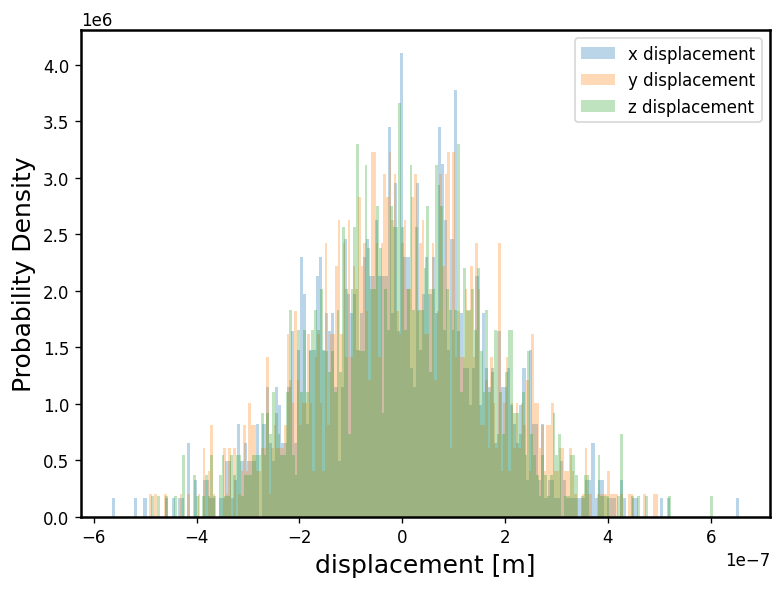

In [6]:
%matplotlib inline
fig2 = plt.figure(dpi=120, constrained_layout=True)
ax2 = fig2.add_subplot()

XD = np.array(free_sim.TRAJ)
x = XD[:,0,0]
y = XD[:,1,0]
z = XD[:,2,0]
dx = np.diff(x)
dy = np.diff(y)
dz = np.diff(z)

ax2.hist(dx, label='x displacement', density=True, bins=200, alpha=0.3)
ax2.hist(dy, label='y displacement', density=True, bins=200, alpha=0.3)
ax2.hist(dz, label='z displacement', density=True, bins=200, alpha=0.3)
ax2.set_xlabel('displacement [m]')
ax2.set_ylabel('Probability Density')
plt.legend()
plt.show()

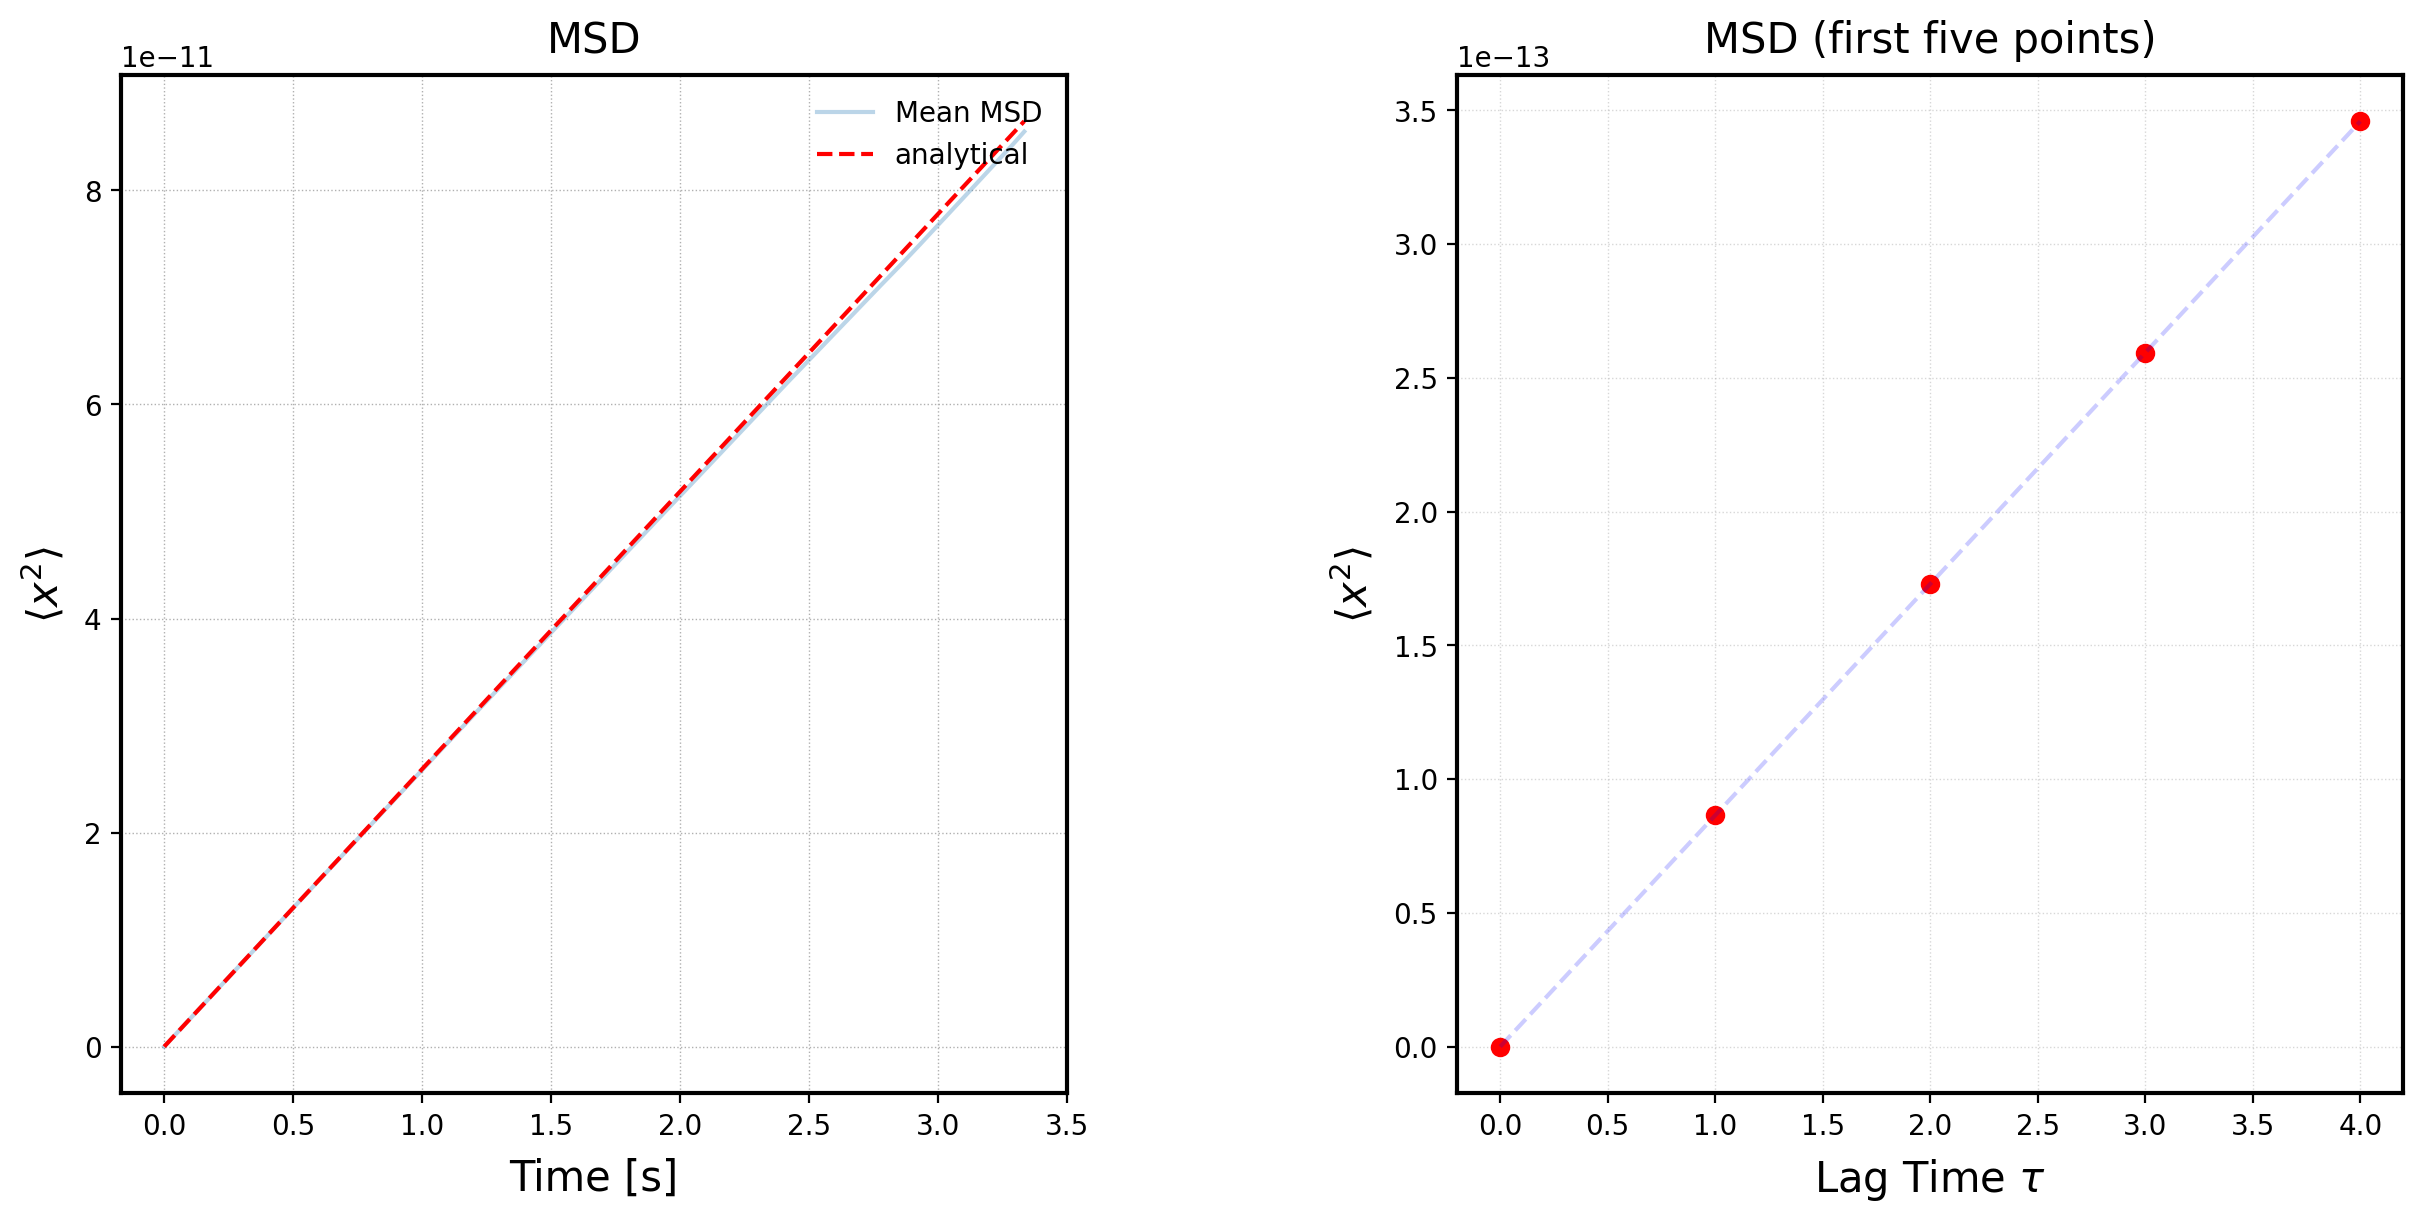

In [7]:
#MSD
# Brownian Evolution Plot
%matplotlib inline
fig4 = plt.figure(figsize=(12,6), dpi=200, constrained_layout=True)
ax4 = fig4.add_subplot(121)
ax5 = fig4.add_subplot(122)
# plot Mean ensemble MSD
free_sim.plotMeanMSD(fig4, ax4)
# True Analytical Curve
time_arr = np.linspace(0, free_sim.dt * free_sim.steps, free_sim.MSD.shape[0])
analytical_line = 6 * D * time_arr
# plotting
ax4.plot(time_arr, analytical_line, 'r--', label='analytical')
ax4.set_title("MSD", pad=8)
ax4.set_xlabel("Time [s]", labelpad=6)
ax4.set_ylabel(r"$\langle x^2 \rangle$", labelpad=6)
ax4.grid(True, which='both', linestyle=':', linewidth=0.5)
ax4.legend(loc='upper right', frameon=False)
# get MSD
free_MSD = free_sim.MSD
# plotting
ax5.plot(np.arange(0, 5, 1),np.mean(free_MSD, axis=1)[:5] , 'ro', label='Ensemble MSD')
ax5.plot(np.arange(0, 5, 1), 6 * D * dt * np.arange(0, 5, 1), 'b--', label="6Ddt", alpha=0.2)
ax5.set_title("MSD (first five points)", pad=8)
ax5.set_xlabel(r"Lag Time $\tau$", labelpad=6)
ax5.set_ylabel(r"$\langle x^2 \rangle$", labelpad=6)
ax5.grid(True, which='both', linestyle=':', linewidth=0.5)
#ax5.legend(loc='upper right', frameon=False)
ax5.grid(alpha=0.5)
plt.show()


In [8]:
fff = np.array(free_sim.TRAJ)
fff1 = fff[:,:,1]
siss = fff1.shape
fff2 = np.reshape(fff1, (siss[1], siss[0]))
fff2.shape

(3, 1001)

In [9]:
def getDiffusion3D(msd, lag, pixel_size, exposure_time, max_time=3):
    time_s = exposure_time * lag
    msd_m2 = msd * pixel_size**2

    # MSD diffusion
    from scipy.optimize import curve_fit
    popt, cov = curve_fit(linear, time_s[:max_time], msd_m2[:max_time]) # m^2/s
    D = popt[0]
    alpha = popt[1]

    return (D/(2 * 3), alpha)

def linear(x, a, b):
    return a * x + b

def compute_covariance_matrix(T):
        """Returns covariance matrix R for Brownian motion (1D, no noise)."""
        R = np.fromfunction(lambda i, j: np.minimum(i + 1, j + 1), (T, T), dtype=int)
        return R

def getDiffusionMLE(trajectory, exposure_time):
        """
        Computes the MLE diffusion coefficient for a 3D trajectory array.

        Parameters:
        - traj_array: np.ndarray of shape (ndim, T) T-length
        - exposure_time: float, time step between trajectory points

        Returns:
        - D_mle: np.ndarray of shape (N,), estimated diffusion coefficients
        """
        traj_array = np.array(trajectory)

        ndim, T = traj_array.shape
        # create covariance matrix
        R = compute_covariance_matrix(T)
        R_inv = np.linalg.inv(R)

        sum_proj = 0.0
        for dim in range(ndim):
            x = traj_array[dim, :] # check
            sum_proj += x @ R_inv @ x  # x^T R^{-1} x

        D_mle = sum_proj / (2 * ndim * (T - 1) * exposure_time)

        return D_mle # this is wrong


R_MSD_array = []
# recover the diffusion coefficient from each MSD vector and plot the recovered Radius from it
#build lag array
lag = np.arange(0, len(free_MSD[:,0]), 1)
for i in tqdm(range(999)):
    # get the msd
    single_particle_MSD = free_MSD[:,i]
    # get the diffusion 
    D_curr = getDiffusion3D(single_particle_MSD, lag, 1, dt, 5)
    # get the radius
    R_MSD_array.append((kb * T)/(6 * np.pi * 10**(-3) * D_curr[0]) * 10**9)

# R_MLE_array = []
# fff = np.array(free_sim.TRAJ)
# for i in tqdm(range(999)):
#     fff1 = fff[:,:,i]
#     siss = fff1.shape
#     single_particle_traj = np.reshape(fff1, (siss[1], siss[0]))

#     # get the diffusion 
#     D_curr = getDiffusionMLE(single_particle_traj, dt)
#     # get the radius
#     R_MLE_array.append((kb * T)/(6 * np.pi * 10**(-3) * D_curr) * 10**9)

    


100%|██████████| 999/999 [00:00<00:00, 10325.17it/s]


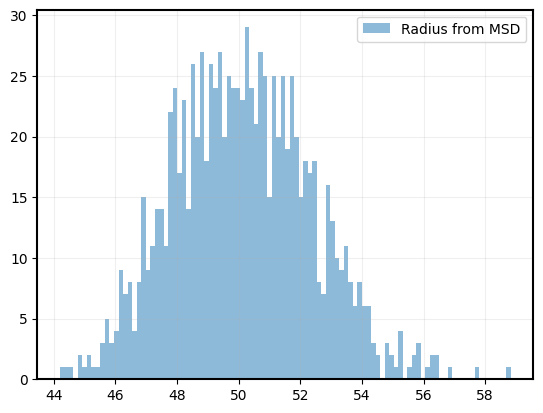

In [10]:
plt.hist(R_MSD_array, bins=100,alpha=0.5, label='Radius from MSD')
plt.grid(alpha=0.2)
#plt.vlines(100, 0, 1,, alpha=0.2)
plt.legend()
plt.show()

In [11]:
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # ------------------------------------------------------------------------------------
# # PLOTTING
# # ------------------------------------------------------------------------------------
# fig = plt.figure(figsize=(10, 4.5), dpi=120, constrained_layout=True)

# gs = gridspec.GridSpec(
#     1, 2,
#     width_ratios=[1.1, 1.6],
#     figure=fig
# )

# ax1 = fig.add_subplot(gs[0, 0], projection='3d')
# ax3 = fig.add_subplot(gs[0, 1])

# # -------------------------------------
# # Trajectory PLOT (3D, normalized)
# # -------------------------------------
# free_sim.plotTrajectory(fig, ax1, particle_index=0)
# ax1.set_title("Trajectory", pad=10)

# #ax1.set_xlim(0, 1)
# #ax1.set_ylim(0, 1)
# #ax1.set_zlim(0, 1)

# ax1.set_xticks([])
# ax1.set_yticks([])
# ax1.set_zticks([])

# ax1.set_xlabel("")
# ax1.set_ylabel("")
# ax1.set_zlabel("")

# # -------------------------------------
# # FREE MSD PLOT
# # -------------------------------------
# free_sim, t_cyl = sims['free']
# #free_sim.plotMeanMSD(fig, ax3)
# time_arr = np.linspace(0, free_sim.dt * free_sim.steps, free_sim.MSD.shape[0])
# analytical_line = 6 * D * time_arr

# ax3.plot(time_arr, analytical_line, 'r--', label='analytical')
# ax3.set_title("MSD", pad=8)
# #ax3.set_xlim(0,15)
# #ax3.set_ylim(0,15)
# ax3.set_xlabel("Time", labelpad=6)
# ax3.set_ylabel(r"$\langle x^2 \rangle$", labelpad=6)
# ax3.grid(True, which='both', linestyle=':', linewidth=0.5)
# ax3.legend(loc='upper right', frameon=False)

# # -------------------------------------
# # Displacement Histogram INSET
# # -------------------------------------
# XD = np.array(free_sim.TRAJ)
# x = XD[:,0,0]
# y = XD[:,1,0]
# z = XD[:,2,0]
# dx = np.diff(x)
# dy = np.diff(y)
# dz = np.diff(z)

# ax2 = inset_axes(
#     ax3,
#     width="35%",
#     height="35%",
#     loc="upper left",
#     borderpad=1.5
# )

# ax2.hist(dx, bins=100, alpha=0.5, label='dx')
# ax2.hist(dy, bins=100, alpha=0.5, label='dy')
# ax2.hist(dz, bins=100, alpha=0.5, label='dz')

# ax2.set_title("Displacement PDF", fontsize=9)
# ax2.tick_params(labelsize=8)
# ax2.legend(frameon=False, fontsize=8)



In [12]:
# --- 
# Rad recovered vs. True Radius
# ---
N = 1000              # number of simultaneous simulations
dt = 1/300              # 1/fps
steps = 1000           # steps
total_time = steps * dt     
T   = 22 + 273.15                       # K                 
box_length_m = 5e-6                # m?

rad_true_array = np.array([20e-9, 30e-9, 40e-9, 50e-9, 80e-9, 100e-9])
diff_true_array = np.array([kb * T / (6 * np.pi * 0.001 * x) for x in rad_true_array])
print(diff_true_array)


[1.08092348e-11 7.20615655e-12 5.40461741e-12 4.32369393e-12
 2.70230870e-12 2.16184696e-12]


In [13]:
rad_measured_array = []
# ------------------------------------------------------------------------------------
# Run Simulation
# ------------------------------------------------------------------------------------
for D_XXX in tqdm(diff_true_array, desc='Radius Index'):
    # run simulation
    free_sim = PeriodicCubeRandomWalkGPT(N, dt, steps, D_XXX, box_length=box_length_m)
    free_sim.runSimulation()
    free_sim.getMeanSquaredDisplacement() # This is good :)
    t_array_free = np.linspace(0, dt * steps, steps)
    sims['free'] = (free_sim, t_array_free)
    # R array set to 0
    R_MSD_array_curr = []
    # recover the diffusion coefficient from each MSD vector and plot the recovered Radius from it
    #build lag array
    free_MSD = free_sim.MSD
    lag = np.arange(0, len(free_MSD[:,0]), 1)
    for i in range(N):
        # get the msd
        single_particle_MSD = free_MSD[:,i]
        # get the diffusion 
        D_curr = getDiffusion3D(single_particle_MSD, lag, 1, dt, 5)
        # get the radius
        R_MSD_array_curr.append((kb * T)/(6 * np.pi * 10**(-3) * D_curr[0]) * 10**9)

    del free_sim

    rad_measured_array.append(R_MSD_array_curr)

Radius Index:   0%|          | 0/6 [00:00<?, ?it/s]

Starting Position: 2.5e-06 
 Diffusion: 1.0809234818215663e-11 



Radius Index:  17%|█▋        | 1/6 [00:03<00:17,  3.49s/it]

Starting Position: 2.5e-06 
 Diffusion: 7.206156545477109e-12 



Radius Index:  33%|███▎      | 2/6 [00:07<00:15,  3.76s/it]

...

Radius Index:  67%|██████▋   | 4/6 [00:15<00:07,  3.86s/it]

Starting Position: 2.5e-06 
 Diffusion: 2.7023087045539157e-12 



Radius Index:  83%|████████▎ | 5/6 [00:19<00:03,  3.83s/it]

Starting Position: 2.5e-06 
 Diffusion: 2.161846963643133e-12 



Radius Index: 100%|██████████| 6/6 [00:22<00:00,  3.80s/it]


In [15]:
particle_variance = np.var(rad_measured_array, axis=1)

/var/folders/_j/przr5xt50dn_lpbmww567g0r0000gn/T/ipykernel_1243/3850154260.py:21: RuntimeWarning: divide by zero encountered in divide
  return (2 * kb**2 * T**2 * dt**2)/(9 * steps * np.pi**2 * 10**(-6) * (rad * 10**(-9))**2)


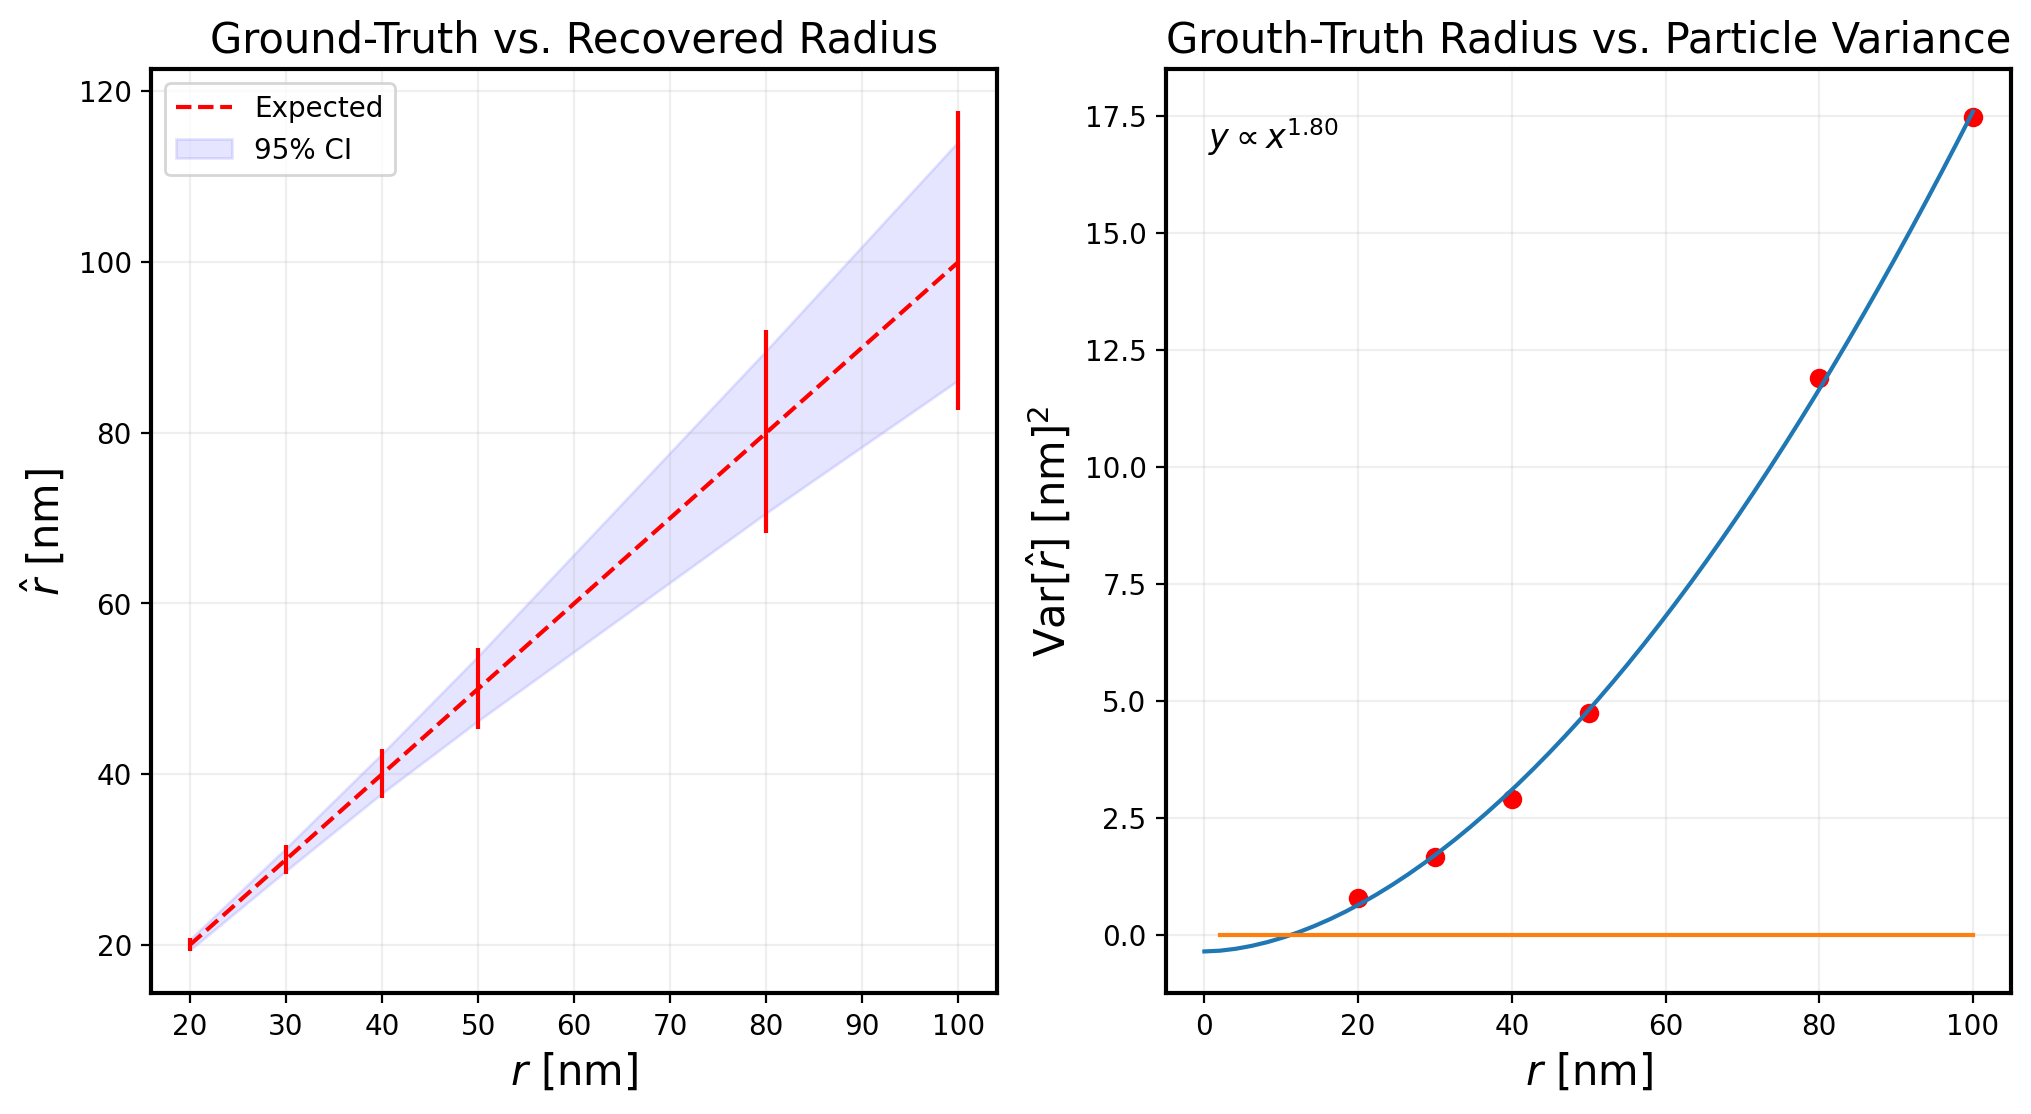

In [52]:

fig1 = plt.figure(figsize=(12,6), dpi=200)
ax1 = fig1.add_subplot(121)
ax2 = fig1.add_subplot(122)

for index, true_radius in enumerate(rad_true_array):
    # for x in rad_measured_array[index]:
    #     ax1.plot(true_radius * 10**9, x, 'bo', alpha=0.008)
    
    ax1.errorbar(true_radius * 10**9, np.mean(rad_measured_array, axis=1)[index], np.var(rad_measured_array, axis=1)[index], color='red')

rad_true = np.array(rad_true_array * 10**9)
ax1.plot(rad_true, rad_true_array * 10**9, 'r--', label='Expected')
ax2.plot(rad_true, particle_variance, 'ro', label=r'\sigma^2')
y =  np.mean(rad_measured_array, axis=1)
ci = 1.96 * particle_variance/np.sqrt(len(y))
ax1.fill_between(rad_true, (y-ci), (y+ci), color='b', alpha=.1, label=r'95% CI')
def variance_model(rad, a, b,c ):
    return a * rad**(b ) + c

def varianceAnalytical(rad):
    return (2 * kb**2 * T**2 * dt**2)/(9 * steps * np.pi**2 * 10**(-6) * (rad * 10**(-9))**2)

from scipy.optimize import curve_fit
param, cov = curve_fit(variance_model, rad_true, particle_variance)
#print(param)
rad_fake = np.linspace(0, np.max(rad_true))
ax2.plot(rad_fake, variance_model(rad_fake, *param), label='power scaling')
ax2.plot(rad_fake, varianceAnalytical(rad_fake), label='analytical model')

label_text = fr"$y \propto  x^{{{param[1]:.2f}}}$"
ax2.text(0.05, 0.95, label_text,
         transform=ax2.transAxes,
         fontsize=12,
         verticalalignment='top')
ax1.grid(alpha=0.2)
ax2.grid(alpha=0.2)
ax1.set_xlabel(r'$r$ [nm]')
ax1.set_ylabel(r'$\hat{r}$ [nm]')
ax1.set_title("Ground-Truth vs. Recovered Radius")
ax2.set_xlabel(r'$r$ [nm]')
ax2.set_ylabel(r'$\text{Var}[\hat{r}]$ [nm]$^2$')
ax2.set_title("Grouth-Truth Radius vs. Particle Variance")

ax1.legend()
plt.show()